# Total Points Dataset (OddsJam Projected Games Line)

Build a match-level train/test frame by joining:
- `refined_fixture_id_mapping` (Sportradar ↔ OddsJam)
- `refined_fixture_stats` (actual points/games, mode_best_of, summary_match_status)
- `refined_consensus` (projected Total Games line)
- Sportradar `event_summary` (competition metadata, start_time, period_scores)

Grain: one row per `sport_event_id`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "injestion").is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError(f"Could not find project root from {cwd}")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from injestion.core.bq import get_client
from injestion.sportradar import SportradarManager
from refined_tables import get_table_id

bq_client = get_client()
sr_manager = SportradarManager()

MAPPING_TABLE_ID = get_table_id("fixture_id_mapping")
FIXTURE_STATS_TABLE_ID = get_table_id("fixture_stats")
CONSENSUS_TABLE_ID = get_table_id("consensus")
EVENT_SUMMARY_TABLE_ID = sr_manager.get_table_id("event_summary")

print(f"mapping:        {MAPPING_TABLE_ID}")
print(f"fixture_stats:  {FIXTURE_STATS_TABLE_ID}")
print(f"consensus:      {CONSENSUS_TABLE_ID}")
print(f"event_summary:  {EVENT_SUMMARY_TABLE_ID}")

mapping:        prizepicksanalytics.originations_tennis.refined_fixture_id_mapping
fixture_stats:  prizepicksanalytics.originations_tennis.refined_fixture_stats
consensus:      prizepicksanalytics.originations_tennis.refined_consensus
event_summary:  prizepicksanalytics.originations_tennis.sr_event_summaries


## Load source tables

In [2]:
def assert_one_to_one(df: pd.DataFrame, col: str, label: str) -> None:
    dup = df[col].duplicated(keep=False)
    n = int(dup.sum())
    if n > 0:
        sample = df.loc[dup, col].astype(str).drop_duplicates().head(10).tolist()
        raise ValueError(f"{label} not 1:1 on {col}: {n} duplicate rows. Sample: {sample}")


mapping_df = bq_client.query(
    f"""
    SELECT sport_event_id, fixture_id
    FROM `{MAPPING_TABLE_ID}`
    """
).to_dataframe()

assert_one_to_one(mapping_df, "sport_event_id", "fixture_id_mapping")
assert_one_to_one(mapping_df, "fixture_id", "fixture_id_mapping")
print(f"mapping rows: {len(mapping_df):,}")
mapping_df.head()

mapping rows: 8,549


,sport_event_id,fixture_id
0,sr:sport_event:72165688,20260624B537891E
1,sr:sport_event:73146812,20260725C0381F0C
2,sr:sport_event:73939664,20260822DDE2928F
3,sr:sport_event:73963714,202608233D957DFE
4,sr:sport_event:66059240,20251126B010E12A


In [3]:
fixture_stats_df = bq_client.query(
    f"""
    SELECT
      sport_event_id,
      total_points,
      total_games_played,
      mode_best_of,
      summary_match_status
    FROM `{FIXTURE_STATS_TABLE_ID}`
    """
).to_dataframe()

fixture_stats_df = fixture_stats_df.drop_duplicates(subset=["sport_event_id"], keep="first")
assert_one_to_one(fixture_stats_df, "sport_event_id", "fixture_stats")
print(f"fixture_stats rows: {len(fixture_stats_df):,}")
fixture_stats_df.head()

fixture_stats rows: 9,480


,sport_event_id,total_points,total_games_played,mode_best_of,summary_match_status
0,sr:sport_event:58213339,74,12,3,ended
1,sr:sport_event:58906357,67,12,3,ended
2,sr:sport_event:59414837,63,12,3,ended
3,sr:sport_event:59551117,63,12,3,ended
4,sr:sport_event:60130357,70,12,3,ended


In [4]:
consensus_tg_df = bq_client.query(
    f"""
    SELECT
      fixture_id,
      market,
      market_id,
      selection_line_key,
      closing_line_points,
      avg_closing_line_price
    FROM `{CONSENSUS_TABLE_ID}`
    WHERE LOWER(market) = 'total games'
       OR LOWER(market_id) = 'total_games'
    """
).to_dataframe()

print(f"consensus Total Games rows: {len(consensus_tg_df):,}")
display(consensus_tg_df["selection_line_key"].value_counts(dropna=False).to_frame("rows"))
consensus_tg_df.head()

consensus Total Games rows: 36,777


,rows
selection_line_key,
over,18390
under,18387


,fixture_id,market,market_id,selection_line_key,closing_line_points,avg_closing_line_price
0,2026061427AB1D06,Total Games,total_games,over,13.5,144.5
1,202603287B52A419,Total Games,total_games,over,13.5,125.0
2,202602062ECF1C2B,Total Games,total_games,over,13.5,-122.0
3,2026013180D68B05,Total Games,total_games,over,13.5,102.0
4,wta:2098DE7F4707,Total Games,total_games,over,13.5,107.0


In [5]:
event_summary_df = bq_client.query(
    f"""
    SELECT
      sport_event_id,
      category_name,
      competition_level,
      start_time,
      competition_gender,
      competition_name,
      competition_id,
      season_id,
      season_name,
      period_scores
    FROM `{EVENT_SUMMARY_TABLE_ID}`
    """
).to_dataframe()

event_summary_df = event_summary_df.drop_duplicates(subset=["sport_event_id"], keep="first")
assert_one_to_one(event_summary_df, "sport_event_id", "event_summary")
print(f"event_summary rows: {len(event_summary_df):,}")
event_summary_df.head()

event_summary rows: 34,410


,sport_event_id,category_name,competition_level,start_time,competition_gender,competition_name,competition_id,season_id,season_name,period_scores
0,sr:sport_event:70282900,ATP,atp_250,2026-04-04 13:50:00+00:00,men,"ATP Bucharest, Romania Men Singles",sr:competition:3007,sr:season:134097,"ATP Bucharest, Romania Men Singles 2026","[{""home_score"": 7, ""away_score"": 6, ""type"": ""s..."
1,sr:sport_event:70282902,ATP,atp_250,2026-04-04 10:00:00+00:00,men,"ATP Bucharest, Romania Men Singles",sr:competition:3007,sr:season:134097,"ATP Bucharest, Romania Men Singles 2026","[{""home_score"": 5, ""away_score"": 7, ""type"": ""s..."
2,sr:sport_event:70719422,ATP,atp_500,2026-04-11 08:30:00+00:00,men,"ATP Barcelona, Spain Men Singles",sr:competition:2769,sr:season:134339,"ATP Barcelona, Spain Men Singles 2026","[{""home_score"": 2, ""away_score"": 6, ""type"": ""s..."
3,sr:sport_event:70719404,ATP,atp_500,2026-04-11 15:10:00+00:00,men,"ATP Barcelona, Spain Men Singles",sr:competition:2769,sr:season:134339,"ATP Barcelona, Spain Men Singles 2026","[{""home_score"": 1, ""away_score"": 6, ""type"": ""s..."
4,sr:sport_event:70719410,ATP,atp_500,2026-04-11 12:50:00+00:00,men,"ATP Barcelona, Spain Men Singles",sr:competition:2769,sr:season:134339,"ATP Barcelona, Spain Men Singles 2026","[{""home_score"": 6, ""away_score"": 4, ""type"": ""s..."


## Collapse Total Games to one projected line per fixture

In [6]:
def build_total_games_lines(consensus_tg: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    One row per fixture_id with projected_total_games.

    Excludes fixtures where over/under closing_line_points disagree.
    Returns (accepted_lines, excluded_conflict_rows).
    """
    work = consensus_tg.copy()
    work["selection_line_key"] = (
        work["selection_line_key"].astype("string").str.lower().str.strip()
    )

    nunique_points = work.groupby("fixture_id")["closing_line_points"].nunique(dropna=True)
    conflict_ids = set(nunique_points[nunique_points > 1].index.astype(str))
    excluded = work.loc[work["fixture_id"].astype(str).isin(conflict_ids)].copy()

    clean = work.loc[~work["fixture_id"].astype(str).isin(conflict_ids)].copy()
    if clean.empty:
        empty_cols = [
            "fixture_id",
            "projected_total_games",
            "projected_total_games_over_price",
            "projected_total_games_under_price",
        ]
        return pd.DataFrame(columns=empty_cols), excluded

    points = (
        clean.groupby("fixture_id", as_index=False)["closing_line_points"]
        .first()
        .rename(columns={"closing_line_points": "projected_total_games"})
    )

    over_price = (
        clean.loc[clean["selection_line_key"] == "over", ["fixture_id", "avg_closing_line_price"]]
        .drop_duplicates(subset=["fixture_id"], keep="first")
        .rename(columns={"avg_closing_line_price": "projected_total_games_over_price"})
    )
    under_price = (
        clean.loc[clean["selection_line_key"] == "under", ["fixture_id", "avg_closing_line_price"]]
        .drop_duplicates(subset=["fixture_id"], keep="first")
        .rename(columns={"avg_closing_line_price": "projected_total_games_under_price"})
    )

    lines = points.merge(over_price, on="fixture_id", how="left").merge(
        under_price, on="fixture_id", how="left"
    )
    lines = lines.dropna(subset=["projected_total_games"]).reset_index(drop=True)
    return lines, excluded


total_games_lines, total_games_conflicts = build_total_games_lines(consensus_tg_df)
print(f"Total Games fixtures kept:      {len(total_games_lines):,}")
print(f"Fixtures excluded (point conflict): {total_games_conflicts['fixture_id'].nunique() if not total_games_conflicts.empty else 0:,}")
if not total_games_conflicts.empty:
    display(
        total_games_conflicts.groupby("fixture_id")["closing_line_points"]
        .agg(["nunique", "min", "max"])
        .sort_values("nunique", ascending=False)
        .head(10)
    )
total_games_lines.head()

Total Games fixtures kept:      18,395
Fixtures excluded (point conflict): 0


,fixture_id,projected_total_games,projected_total_games_over_price,projected_total_games_under_price
0,0038CFAB1598,23.5,-118.000000,-113.000000
1,0372116C47CB,22.5,-111.363636,-118.909091
2,03F6F3F335E9,19.5,-112.444444,-120.777778
3,061F7DDF065B,21.5,-119.600000,-115.400000
4,063EC2E79B42,20.5,-110.000000,-124.000000


## Join unified match table

In [7]:
n_map = len(mapping_df)

step1 = mapping_df.merge(fixture_stats_df, on="sport_event_id", how="inner")
n_with_stats = len(step1)

step2 = step1.merge(total_games_lines, on="fixture_id", how="inner")
n_with_line = len(step2)

unified_raw = step2.merge(event_summary_df, on="sport_event_id", how="left")
n_with_summary_hit = int(unified_raw["category_name"].notna().sum())

print("Join funnel")
print(f"  mapping:                    {n_map:,}")
print(f"  + fixture_stats (inner):    {n_with_stats:,}  (dropped {n_map - n_with_stats:,})")
print(f"  + total_games line (inner): {n_with_line:,}  (dropped {n_with_stats - n_with_line:,})")
print(f"  + event_summary (left):     {len(unified_raw):,} rows, {n_with_summary_hit:,} with category_name")

unified_cols = [
    "sport_event_id",
    "fixture_id",
    "total_points",
    "projected_total_games",
    "total_games_played",
    "category_name",
    "competition_level",
    "mode_best_of",
    "start_time",
    "competition_gender",
    "competition_name",
    "competition_id",
    "season_id",
    "season_name",
    "period_scores",
    "summary_match_status",
    "projected_total_games_over_price",
    "projected_total_games_under_price",
]
unified_df = unified_raw.loc[:, unified_cols].copy()
assert_one_to_one(unified_df, "sport_event_id", "unified_df")
assert_one_to_one(unified_df, "fixture_id", "unified_df")
print(f"\nunified_df rows: {len(unified_df):,}")
unified_df.head(10)

Join funnel
  mapping:                    8,549
  + fixture_stats (inner):    8,549  (dropped 0)
  + total_games line (inner): 8,544  (dropped 5)
  + event_summary (left):     8,544 rows, 8,544 with category_name

unified_df rows: 8,544


,sport_event_id,fixture_id,total_points,projected_total_games,total_games_played,category_name,competition_level,mode_best_of,start_time,competition_gender,competition_name,competition_id,season_id,season_name,period_scores,summary_match_status,projected_total_games_over_price,projected_total_games_under_price
0,sr:sport_event:72165688,20260624B537891E,129,20.5,18,ATP,atp_250,3,2026-06-24 15:30:00+00:00,men,"ATP Mallorca, Spain Men Singles",sr:competition:31475,sr:season:134693,"ATP Mallorca, Spain Men Singles 2026","[{""home_score"": 2, ""away_score"": 6, ""type"": ""s...",ended,-128.500000,-2.166667
1,sr:sport_event:73146812,20260725C0381F0C,146,22.5,23,ATP,atp_500,3,2026-07-25 16:30:00+00:00,men,"ATP Washington, USA Men Singles",sr:competition:2971,sr:season:134781,"ATP Washington, USA Men Singles 2026","[{""home_score"": 6, ""away_score"": 4, ""type"": ""s...",ended,-115.000000,-115.000000
2,sr:sport_event:73939664,20260822DDE2928F,180,22.5,30,ATP,atp_250,3,2026-08-22 18:15:00+00:00,men,"ATP Winston Salem, USA Men Singles",sr:competition:4329,sr:season:134983,"ATP Winston Salem, USA Men Singles 2026","[{""home_score"": 2, ""away_score"": 6, ""type"": ""s...",ended,-111.250000,-127.500000
3,sr:sport_event:73963714,202608233D957DFE,168,23.5,27,ATP,atp_250,3,2026-08-23 17:10:00+00:00,men,"ATP Winston Salem, USA Men Singles",sr:competition:4329,sr:season:134983,"ATP Winston Salem, USA Men Singles 2026","[{""home_score"": 6, ""away_score"": 3, ""type"": ""s...",ended,-111.333333,-124.666667
4,sr:sport_event:66059240,20251126B010E12A,147,20.5,23,WTA,None,3,2025-11-26 02:00:00+00:00,women,AO Asia-Pacific Wildcard Playoff Women Singles,sr:competition:14670,sr:season:137232,AO Asia-Pacific Wildcard Playoff Women Singles...,"[{""home_score"": 6, ""away_score"": 7, ""type"": ""s...",ended,-119.333333,-113.333333
5,sr:sport_event:71582894,2026051947CBA2BA,115,20.5,19,ATP,grand_slam,3,2026-05-20 08:00:00+00:00,men,French Open Men Singles,sr:competition:2579,sr:season:131405,French Open Men Singles 2026,"[{""home_score"": 6, ""away_score"": 4, ""type"": ""s...",ended,-116.000000,-116.875000
6,sr:sport_event:72986826,202607205DD75900,167,22.5,29,ATP,atp_250,3,2026-07-20 12:50:00+00:00,men,"ATP Kitzbuhel, Austria Men Singles",sr:competition:3151,sr:season:134721,"ATP Kitzbuhel, Austria Men Singles 2026","[{""home_score"": 4, ""away_score"": 6, ""type"": ""s...",ended,-112.000000,-121.888889
7,sr:sport_event:72827342,2026072288EF2411,123,23.5,21,ATP,atp_250,3,2026-07-22 14:10:00+00:00,men,"ATP Kitzbuhel, Austria Men Singles",sr:competition:3151,sr:season:134721,"ATP Kitzbuhel, Austria Men Singles 2026","[{""home_score"": 6, ""away_score"": 3, ""type"": ""s...",ended,46.250000,-135.750000
8,sr:sport_event:61402523,202506230C51F1FA,168,20.5,29,ATP,grand_slam,3,2025-06-23 13:30:00+00:00,men,Wimbledon Men Singles,sr:competition:2555,sr:season:120983,Wimbledon Men Singles 2025,"[{""home_score"": 6, ""away_score"": 7, ""type"": ""s...",ended,-109.750000,-123.750000
9,sr:sport_event:71622066,202605217A338674,197,22.5,31,ATP,grand_slam,3,2026-05-21 09:00:00+00:00,men,French Open Men Singles,sr:competition:2579,sr:season:131405,French Open Men Singles 2026,"[{""home_score"": 7, ""away_score"": 6, ""type"": ""s...",ended,-75.142857,-129.571429


## QC + training filter on `summary_match_status`

In [8]:
from originated_models.total_points_oj_data import (
    BO3_MAX_PROJECTED_TOTAL_GAMES,
    KEEP_COMPETITION_LEVELS,
    filter_bo3_projected_games,
    filter_competition_levels,
)

print("summary_match_status value counts (pre-filter)")
display(unified_df["summary_match_status"].value_counts(dropna=False).to_frame("rows"))

# Default: keep only fully completed matches.
KEEP_MATCH_STATUSES = {"ended"}

n_before = len(unified_df)
status_norm = unified_df["summary_match_status"].astype("string").str.lower().str.strip()
ended_df = unified_df.loc[status_norm.isin(KEEP_MATCH_STATUSES)].copy()
n_after_status = len(ended_df)

print(f"\nTraining filter KEEP_MATCH_STATUSES={sorted(KEEP_MATCH_STATUSES)}")
print(f"  before: {n_before:,}")
print(f"  after:  {n_after_status:,}")
print(f"  dropped: {n_before - n_after_status:,}")

dropped_status = (
    unified_df.loc[~status_norm.isin(KEEP_MATCH_STATUSES), "summary_match_status"]
    .value_counts(dropna=False)
    .to_frame("dropped_rows")
)
if not dropped_status.empty:
    print("\nDropped by status:")
    display(dropped_status)

# Core tour levels only (drop Tour Finals / Next Gen / null / etc.).
level_df, level_diag = filter_competition_levels(
    ended_df, keep_levels=KEEP_COMPETITION_LEVELS
)
print("\nCompetition level allowlist filter")
print(f"  keep: {sorted(KEEP_COMPETITION_LEVELS)}")
print(f"  before: {level_diag['n_before_competition_level_filter']:,}")
print(f"  dropped: {level_diag['n_competition_level_filter_dropped']:,}")
print(f"  after: {level_diag['n_after_competition_level_filter']:,}")
if level_diag["dropped_competition_levels"]:
    print("  dropped by level:")
    for lvl, n in sorted(
        level_diag["dropped_competition_levels"].items(), key=lambda kv: (-kv[1], kv[0])
    ):
        print(f"    {lvl}: {n:,}")

# Bo3: drop implausible OddsJam total-games lines (>= 30).
train_df, bo3_diag = filter_bo3_projected_games(
    level_df, max_projected_games=BO3_MAX_PROJECTED_TOTAL_GAMES
)
print(
    f"\nBo3 projected_total_games < {BO3_MAX_PROJECTED_TOTAL_GAMES:g} filter"
)
print(f"  bo3 before: {bo3_diag['n_bo3_before_proj_filter']:,}")
print(f"  bo3 dropped: {bo3_diag['n_bo3_proj_filter_dropped']:,}")
print(f"  bo3 after: {bo3_diag['n_bo3_after_proj_filter']:,}")
print(f"  train_df rows: {len(train_df):,}")

summary_match_status value counts (pre-filter)


,rows
summary_match_status,
ended,8544



Training filter KEEP_MATCH_STATUSES=['ended']
  before: 8,544
  after:  8,544
  dropped: 0


In [9]:
def missingness_report(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n = len(df)
    for col in cols:
        miss = int(df[col].isna().sum())
        rows.append({"column": col, "missing": miss, "missing_pct": miss / n if n else None})
    return pd.DataFrame(rows)


print("Missingness on train_df")
display(
    missingness_report(
        train_df,
        [
            "projected_total_games",
            "total_points",
            "total_games_played",
            "category_name",
            "start_time",
            "mode_best_of",
            "competition_level",
        ],
    )
)

print("\ncategory_name value counts")
display(train_df["category_name"].value_counts(dropna=False).head(20).to_frame("rows"))

print("\nmode_best_of value counts")
display(train_df["mode_best_of"].value_counts(dropna=False).to_frame("rows"))

if not train_df.empty:
    print("\nprojected_total_games vs total_games_played")
    display(
        train_df[["projected_total_games", "total_games_played", "total_points"]]
        .describe()
        .T
    )

Missingness on train_df


,column,missing,missing_pct
0,projected_total_games,0,0.000000
1,total_points,0,0.000000
2,total_games_played,0,0.000000
3,category_name,0,0.000000
4,start_time,0,0.000000
5,mode_best_of,0,0.000000
6,competition_level,8,0.000936



category_name value counts


,rows
category_name,
ATP,5047
WTA,3497



mode_best_of value counts


,rows
mode_best_of,
3,8023
5,521



projected_total_games vs total_games_played


,count,mean,std,min,25%,50%,75%,max
projected_total_games,8544.0,22.510183,3.965977,14.5,20.5,21.5,22.5,44.5
total_games_played,8544.0,23.527739,6.936978,12.0,18.0,22.0,28.0,61.0
total_points,8544.0,150.148174,45.968469,63.0,115.0,140.0,180.0,395.0


In [10]:
# Optional tighter filter skeleton (not applied to train_df by default).
optional = train_df.copy()
n0 = len(optional)
optional = optional.loc[
    optional["category_name"].astype("string").str.upper().isin(["ATP", "WTA"])
]
n1 = len(optional)
optional = optional.dropna(subset=["projected_total_games", "total_points", "total_games_played"])
n2 = len(optional)

print("Optional filter coverage (not applied to train_df)")
print(f"  train_df:                 {n0:,}")
print(f"  ATP/WTA only:             {n1:,}  (dropped {n0 - n1:,})")
print(f"  + non-null points/games:  {n2:,}  (dropped {n1 - n2:,})")

Optional filter coverage (not applied to train_df)
  train_df:                 8,544
  ATP/WTA only:             8,544  (dropped 0)
  + non-null points/games:  8,544  (dropped 0)


In [11]:
spot_cols = [
    "sport_event_id",
    "fixture_id",
    "summary_match_status",
    "category_name",
    "season_name",
    "mode_best_of",
    "projected_total_games",
    "total_games_played",
    "total_points",
    "start_time",
    "competition_name",
]

if train_df.empty:
    print("train_df is empty — nothing to spot-check.")
else:
    sample_n = min(20, len(train_df))
    display(train_df.sample(sample_n, random_state=42)[spot_cols].sort_values("start_time"))

print(f"\nReady for modeling: train_df has {len(train_df):,} rows")
train_df.head()

,sport_event_id,fixture_id,summary_match_status,category_name,season_name,mode_best_of,projected_total_games,total_games_played,total_points,start_time,competition_name
4046,sr:sport_event:59383229,2025033130836715,ended,ATP,"ATP Bucharest, Romania Men Singles 2025",3,21.5,29,191,2025-03-31 14:00:00+00:00,"ATP Bucharest, Romania Men Singles"
4723,sr:sport_event:59388349,20250331AB91CEB6,ended,WTA,"WTA Charleston, USA Women Singles 2025",3,21.5,17,111,2025-03-31 15:00:00+00:00,"WTA Charleston, USA Women Singles"
2829,sr:sport_event:59611439,2025040621887915,ended,ATP,"ATP Monte Carlo, Monaco Men Singles 2025",3,20.5,26,184,2025-04-06 09:00:00+00:00,"ATP Monte Carlo, Monaco Men Singles"
7435,sr:sport_event:59819562,202504145EF9792C,ended,ATP,"ATP Munich, Germany Men Singles 2025",3,22.5,32,203,2025-04-15 09:00:00+00:00,"ATP Munich, Germany Men Singles"
748,sr:sport_event:60048341,20250422BE2149CD,ended,ATP,"ATP Madrid, Spain Men Singles 2025",3,22.5,28,182,2025-04-24 09:00:00+00:00,"ATP Madrid, Spain Men Singles"
3715,sr:sport_event:60122205,202504245EB4C823,ended,ATP,"ATP Madrid, Spain Men Singles 2025",3,22.5,15,75,2025-04-24 10:55:00+00:00,"ATP Madrid, Spain Men Singles"
4035,sr:sport_event:60645955,20250520CF5A06CC,ended,WTA,French Open Women Singles 2025,3,18.5,17,105,2025-05-20 09:55:00+00:00,French Open Women Singles
2145,sr:sport_event:60690853,20250530D242F343,ended,WTA,French Open Women Singles 2025,3,19.5,16,110,2025-05-31 09:00:00+00:00,French Open Women Singles
3534,sr:sport_event:61293445,20250625E5648951,ended,ATP,"ATP Eastbourne, Great Britain Men Singles 2025",3,23.5,19,119,2025-06-25 12:00:00+00:00,"ATP Eastbourne, Great Britain Men Singles"
3404,sr:sport_event:61451541,20250625E168027A,ended,WTA,Wimbledon Women Singles 2025,3,21.0,38,254,2025-06-25 15:25:00+00:00,Wimbledon Women Singles



Ready for modeling: train_df has 8,544 rows


,sport_event_id,fixture_id,total_points,projected_total_games,total_games_played,category_name,competition_level,mode_best_of,start_time,competition_gender,competition_name,competition_id,season_id,season_name,period_scores,summary_match_status,projected_total_games_over_price,projected_total_games_under_price
0,sr:sport_event:72165688,20260624B537891E,129,20.5,18,ATP,atp_250,3,2026-06-24 15:30:00+00:00,men,"ATP Mallorca, Spain Men Singles",sr:competition:31475,sr:season:134693,"ATP Mallorca, Spain Men Singles 2026","[{""home_score"": 2, ""away_score"": 6, ""type"": ""s...",ended,-128.500000,-2.166667
1,sr:sport_event:73146812,20260725C0381F0C,146,22.5,23,ATP,atp_500,3,2026-07-25 16:30:00+00:00,men,"ATP Washington, USA Men Singles",sr:competition:2971,sr:season:134781,"ATP Washington, USA Men Singles 2026","[{""home_score"": 6, ""away_score"": 4, ""type"": ""s...",ended,-115.000000,-115.000000
2,sr:sport_event:73939664,20260822DDE2928F,180,22.5,30,ATP,atp_250,3,2026-08-22 18:15:00+00:00,men,"ATP Winston Salem, USA Men Singles",sr:competition:4329,sr:season:134983,"ATP Winston Salem, USA Men Singles 2026","[{""home_score"": 2, ""away_score"": 6, ""type"": ""s...",ended,-111.250000,-127.500000
3,sr:sport_event:73963714,202608233D957DFE,168,23.5,27,ATP,atp_250,3,2026-08-23 17:10:00+00:00,men,"ATP Winston Salem, USA Men Singles",sr:competition:4329,sr:season:134983,"ATP Winston Salem, USA Men Singles 2026","[{""home_score"": 6, ""away_score"": 3, ""type"": ""s...",ended,-111.333333,-124.666667
4,sr:sport_event:66059240,20251126B010E12A,147,20.5,23,WTA,None,3,2025-11-26 02:00:00+00:00,women,AO Asia-Pacific Wildcard Playoff Women Singles,sr:competition:14670,sr:season:137232,AO Asia-Pacific Wildcard Playoff Women Singles...,"[{""home_score"": 6, ""away_score"": 7, ""type"": ""s...",ended,-119.333333,-113.333333


## Season coverage snapshot (Apr 2026 – Sep 2026)

One row per season × competition_level × category_name, using `train_df` match start times.

In [12]:
# Season-level coverage for potential test-window planning.
season_window_start = pd.Timestamp("2026-04-01", tz="UTC")
season_window_end = pd.Timestamp("2026-09-30 23:59:59", tz="UTC")

season_base = train_df.copy()
season_base["start_time"] = pd.to_datetime(season_base["start_time"], utc=True, errors="coerce")

season_summary = (
    season_base.dropna(subset=["season_id", "start_time"])
    .groupby(["season_id", "season_name", "competition_level", "category_name"], dropna=False)
    .agg(
        first_match_date=("start_time", "min"),
        total_matches=("sport_event_id", "size"),
    )
    .reset_index()
)

season_summary_apr_sep_2026 = (
    season_summary.loc[
        (season_summary["first_match_date"] >= season_window_start)
        & (season_summary["first_match_date"] <= season_window_end)
    ]
    .sort_values("first_match_date", ascending=False)
    .reset_index(drop=True)
)

print(f"Seasons with first_match_date in Apr–Sep 2026: {len(season_summary_apr_sep_2026):,}")
season_summary_apr_sep_2026[
    [
        "season_name",
        "competition_level",
        "category_name",
        "first_match_date",
        "total_matches",
    ]
]

Seasons with first_match_date in Apr–Sep 2026: 55


,season_name,competition_level,category_name,first_match_date,total_matches
0,"ATP Chengdu, China Men Singles 2026",atp_250,ATP,2026-09-22 05:00:00+00:00,12
1,"ATP Hangzhou, China Men Singles 2026",atp_250,ATP,2026-09-22 04:00:00+00:00,13
2,"WTA Seoul, Korea Republic Women Singles 2026",wta_250,WTA,2026-09-19 05:30:00+00:00,13
3,"WTA Singapore, Singapore Women Singles 2026",wta_500,WTA,2026-09-19 03:10:00+00:00,11
4,"WTA Sao Paulo, Brazil Women, Singles 2026",wta_250,WTA,2026-09-12 22:45:00+00:00,12
5,"WTA Guadalajara, Mexico Women Singles 2026",wta_500,WTA,2026-09-12 16:00:00+00:00,13
6,US Open Women Singles 2026,grand_slam,WTA,2026-08-24 15:00:00+00:00,115
7,US Open Men Singles 2026,grand_slam,ATP,2026-08-24 15:00:00+00:00,115
8,"WTA Monterrey, Mexico Women Singles 2026",wta_500,WTA,2026-08-22 20:45:00+00:00,14
9,"ATP Winston Salem, USA Men Singles 2026",atp_250,ATP,2026-08-22 15:00:00+00:00,52


## Train / test split (tournament start cutoff)

**Rule:** assign by *tournament* start, not individual match date.
- Compute each season's `first_match_date`
- If `first_match_date >= 2026-06-06` (WTA 's-Hertogenbosch) → **test**
- Else → **train**

This keeps late matches from older tournaments (e.g. French Open) out of the test set.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

TEST_CUTOFF = pd.Timestamp("2026-06-06", tz="UTC")

split_base = train_df.copy()
split_base["start_time"] = pd.to_datetime(split_base["start_time"], utc=True, errors="coerce")

tournament_starts = (
    split_base.dropna(subset=["season_id", "start_time"])
    .groupby("season_id", as_index=False)
    .agg(
        season_name=("season_name", "first"),
        category_name=("category_name", "first"),
        competition_level=("competition_level", "first"),
        first_match_date=("start_time", "min"),
        n_matches=("sport_event_id", "size"),
    )
)
tournament_starts["split"] = np.where(
    tournament_starts["first_match_date"] >= TEST_CUTOFF, "test", "train"
)

split_base = split_base.merge(
    tournament_starts[["season_id", "first_match_date", "split"]],
    on="season_id",
    how="left",
)
# Matches missing season_id / start_time cannot be assigned by tournament start
unassigned = split_base["split"].isna().sum()
if unassigned:
    print(f"Warning: {unassigned:,} matches missing season_id/start_time left unassigned")

train_split_df = split_base.loc[split_base["split"] == "train"].copy()
test_split_df = split_base.loc[split_base["split"] == "test"].copy()

print(f"Cutoff: tournament first_match_date >= {TEST_CUTOFF.date()}")
print(f"Tournaments — train: {(tournament_starts['split']=='train').sum():,} | test: {(tournament_starts['split']=='test').sum():,}")
print(f"Matches     — train: {len(train_split_df):,} | test: {len(test_split_df):,} | total: {len(split_base):,}")
print(f"Test share of matches: {len(test_split_df) / len(split_base):.1%}" if len(split_base) else "")

print("\nEarliest test tournaments:")
display(
    tournament_starts.loc[tournament_starts["split"] == "test"]
    .sort_values("first_match_date")
    .head(10)[["season_name", "competition_level", "category_name", "first_match_date", "n_matches"]]
)

Cutoff: tournament first_match_date >= 2026-06-06
Tournaments — train: 144 | test: 39
Matches     — train: 6,995 | test: 1,549 | total: 8,544
Test share of matches: 18.1%

Earliest test tournaments:


,season_name,competition_level,category_name,first_match_date,n_matches
122,"ATP S-Hertogenbosch, Netherlands Men Singles 2026",atp_250,ATP,2026-06-06 09:00:00+00:00,27
123,"ATP Stuttgart, Germany Men Singles 2026",atp_250,ATP,2026-06-06 09:00:00+00:00,33
163,"WTA S-Hertogenbosch, Netherlands Women Singles...",wta_250,WTA,2026-06-06 09:00:00+00:00,16
164,"WTA London, Great Britain Women Singles 2026",wta_500,WTA,2026-06-07 09:30:00+00:00,9
124,"ATP Halle, Germany Men Singles 2026",atp_500,ATP,2026-06-13 09:00:00+00:00,42
166,"WTA Nottingham, Great Britain Women Singles 2026",wta_250,WTA,2026-06-13 10:00:00+00:00,28
165,"Berlin, Germany Women Singles 2026",wta_500,WTA,2026-06-13 10:10:00+00:00,18
125,"ATP London, Great Britain Men Singles 2026",atp_500,ATP,2026-06-13 11:00:00+00:00,37
126,"ATP Mallorca, Spain Men Singles 2026",atp_250,ATP,2026-06-20 09:00:00+00:00,32
167,"WTA Bad Homburg, Germany Women Singles 2026",wta_500,WTA,2026-06-20 09:00:00+00:00,13


## Test-set coverage diagnostics

**What we want to see**
1. Share of each `competition_level`'s matches that land in test
2. Share of ATP vs WTA matches in test
3. Tournament counts by `competition_level`: test vs full dataset

**Viz layout (2×2)**
- Top-left: % of matches in test by competition level (horizontal bars — easiest to compare balance)
- Top-right: % of matches in test by ATP / WTA
- Bottom-left: match counts train vs test by competition level
- Bottom-right: tournament counts (unique `season_id`) total vs test by competition level

In [14]:
def _pct(numer: float, denom: float) -> float:
    return float(numer) / float(denom) if denom else np.nan


assigned = split_base.loc[split_base["split"].notna()].copy()

# --- Tables ---
level_match_coverage = (
    assigned.groupby("competition_level", dropna=False)
    .agg(
        total_matches=("sport_event_id", "size"),
        test_matches=("split", lambda s: int((s == "test").sum())),
    )
    .reset_index()
)
level_match_coverage["train_matches"] = (
    level_match_coverage["total_matches"] - level_match_coverage["test_matches"]
)
level_match_coverage["pct_matches_in_test"] = level_match_coverage.apply(
    lambda r: _pct(r["test_matches"], r["total_matches"]), axis=1
)
level_match_coverage = level_match_coverage.sort_values(
    "total_matches", ascending=False
).reset_index(drop=True)

category_match_coverage = (
    assigned.groupby("category_name", dropna=False)
    .agg(
        total_matches=("sport_event_id", "size"),
        test_matches=("split", lambda s: int((s == "test").sum())),
    )
    .reset_index()
)
category_match_coverage["train_matches"] = (
    category_match_coverage["total_matches"] - category_match_coverage["test_matches"]
)
category_match_coverage["pct_matches_in_test"] = category_match_coverage.apply(
    lambda r: _pct(r["test_matches"], r["total_matches"]), axis=1
)
category_match_coverage = category_match_coverage.sort_values(
    "category_name"
).reset_index(drop=True)

level_tournament_coverage = (
    tournament_starts.groupby("competition_level", dropna=False)
    .agg(
        total_tournaments=("season_id", "nunique"),
        test_tournaments=("split", lambda s: int((s == "test").sum())),
    )
    .reset_index()
)
level_tournament_coverage["train_tournaments"] = (
    level_tournament_coverage["total_tournaments"]
    - level_tournament_coverage["test_tournaments"]
)
level_tournament_coverage["pct_tournaments_in_test"] = level_tournament_coverage.apply(
    lambda r: _pct(r["test_tournaments"], r["total_tournaments"]), axis=1
)
level_tournament_coverage = level_tournament_coverage.sort_values(
    "total_tournaments", ascending=False
).reset_index(drop=True)

print("Match coverage by competition_level")
display(
    level_match_coverage.assign(
        pct_matches_in_test=lambda d: d["pct_matches_in_test"].map(
            lambda x: f"{x:.1%}" if pd.notna(x) else None
        )
    )
)

print("Match coverage by category_name (ATP / WTA)")
display(
    category_match_coverage.assign(
        pct_matches_in_test=lambda d: d["pct_matches_in_test"].map(
            lambda x: f"{x:.1%}" if pd.notna(x) else None
        )
    )
)

print("Tournament coverage by competition_level")
display(
    level_tournament_coverage.assign(
        pct_tournaments_in_test=lambda d: d["pct_tournaments_in_test"].map(
            lambda x: f"{x:.1%}" if pd.notna(x) else None
        )
    )
)

Match coverage by competition_level


,competition_level,total_matches,test_matches,train_matches,pct_matches_in_test
0,grand_slam,2030,465,1565,22.9%
1,atp_1000,1614,206,1408,12.8%
2,atp_250,1546,392,1154,25.4%
3,wta_1000,1089,114,975,10.5%
4,atp_500,872,122,750,14.0%
5,wta_250,771,153,618,19.8%
6,wta_500,607,97,510,16.0%
7,NaN,8,0,8,0.0%
8,atp_world_tour_finals,3,0,3,0.0%
9,wta_championships,3,0,3,0.0%


Match coverage by category_name (ATP / WTA)


,category_name,total_matches,test_matches,train_matches,pct_matches_in_test
0,ATP,5047,940,4107,18.6%
1,WTA,3497,609,2888,17.4%


Tournament coverage by competition_level


,competition_level,total_tournaments,test_tournaments,train_tournaments,pct_tournaments_in_test
0,atp_250,47,13,34,27.7%
1,wta_250,34,8,26,23.5%
2,wta_500,27,7,20,25.9%
3,atp_500,24,3,21,12.5%
4,atp_1000,16,2,14,12.5%
5,wta_1000,16,2,14,12.5%
6,grand_slam,14,4,10,28.6%
7,NaN,2,0,2,0.0%
8,atp_next_generation,1,0,1,0.0%
9,atp_world_tour_finals,1,0,1,0.0%


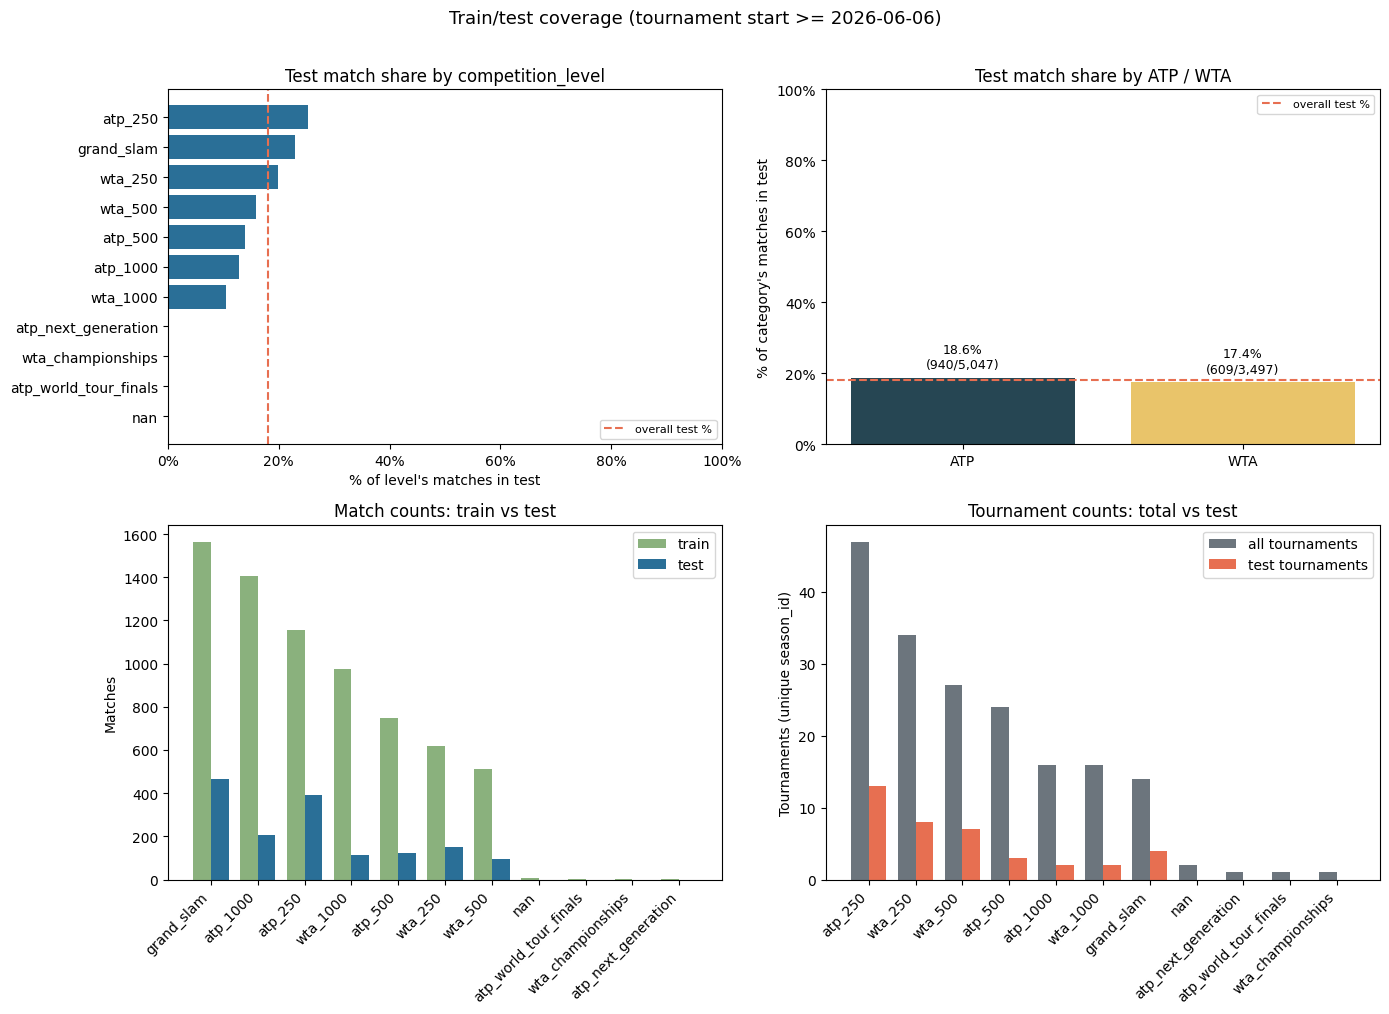

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) % matches in test by competition level
ax = axes[0, 0]
lvl = level_match_coverage.sort_values("pct_matches_in_test", ascending=True)
ax.barh(lvl["competition_level"].astype(str), lvl["pct_matches_in_test"].fillna(0), color="#2a6f97")
ax.axvline(len(test_split_df) / len(assigned) if len(assigned) else 0, color="#e76f51", ls="--", lw=1.5, label="overall test %")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("% of level's matches in test")
ax.set_title("Test match share by competition_level")
ax.legend(loc="lower right", fontsize=8)

# 2) % matches in test by ATP/WTA
ax = axes[0, 1]
cat = category_match_coverage.sort_values("category_name")
bars = ax.bar(cat["category_name"].astype(str), cat["pct_matches_in_test"].fillna(0), color=["#264653", "#e9c46a"])
ax.axhline(len(test_split_df) / len(assigned) if len(assigned) else 0, color="#e76f51", ls="--", lw=1.5, label="overall test %")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylabel("% of category's matches in test")
ax.set_title("Test match share by ATP / WTA")
for bar, pct, n_test, n_tot in zip(
    bars,
    cat["pct_matches_in_test"].fillna(0),
    cat["test_matches"],
    cat["total_matches"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{pct:.1%}\n({n_test:,}/{n_tot:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.legend(loc="upper right", fontsize=8)

# 3) Match counts train vs test by level
ax = axes[1, 0]
lvl_plot = level_match_coverage.sort_values("total_matches", ascending=False)
x = np.arange(len(lvl_plot))
width = 0.38
ax.bar(x - width / 2, lvl_plot["train_matches"], width, label="train", color="#8ab17d")
ax.bar(x + width / 2, lvl_plot["test_matches"], width, label="test", color="#2a6f97")
ax.set_xticks(x)
ax.set_xticklabels(lvl_plot["competition_level"].astype(str), rotation=45, ha="right")
ax.set_ylabel("Matches")
ax.set_title("Match counts: train vs test")
ax.legend()

# 4) Tournament counts total vs test by level
ax = axes[1, 1]
tourn_plot = level_tournament_coverage.sort_values("total_tournaments", ascending=False)
x = np.arange(len(tourn_plot))
ax.bar(x - width / 2, tourn_plot["total_tournaments"], width, label="all tournaments", color="#6c757d")
ax.bar(x + width / 2, tourn_plot["test_tournaments"], width, label="test tournaments", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels(tourn_plot["competition_level"].astype(str), rotation=45, ha="right")
ax.set_ylabel("Tournaments (unique season_id)")
ax.set_title("Tournament counts: total vs test")
ax.legend()

fig.suptitle(
    f"Train/test coverage (tournament start >= {TEST_CUTOFF.date()})",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
plt.show()